## Set Experiment Values

In [4]:
# What is the ID for the current participant?
PARTICIPANT_ID = "jtdawc"
# How many "best" poses do you want?
NUM_POSES_WANTED = 3

## Imports + Initialization

In [5]:
# Imports:
import re
import numpy as np
import math
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from copy import copy
from sklearn.metrics import accuracy_score

In [6]:
# Load result file
input_file = './calibration-results/{}.txt'.format(PARTICIPANT_ID)

results = open(input_file, "r")

## Load Results

In [7]:
# Define the custom object types

class Category:
    def __init__(self, index, score, display_name, category_name):
        self.index = index
        self.score = score
        self.display_name = display_name
        self.category_name = category_name

class NormalizedLandmark:
    def __init__(self, x, y, z, visibility, presence):
        self.x = x
        self.y = y
        self.z = z
        self.visibility = visibility
        self.presence = presence

class Landmark:
    def __init__(self, x, y, z, visibility, presence):
        self.x = x
        self.y = y
        self.z = z
        self.visibility = visibility
        self.presence = presence

In [8]:
# Function to parse all Hand Landmark Result data from one line in the file

def parse(data_string):
    handedness = []
    normalized_landmarks = []
    world_landmarks = []
    # Extract handedness data using regex
    handedness_match = re.search(r'handedness=\[\[.*?\]\]', data_string)
    if handedness_match:
        handedness_data = handedness_match.group()

        # Extract hand_landmarks data using regex
        hand_landmarks_match = re.search(r'hand_landmarks=\[\[.*?\]\]', data_string)
        hand_landmarks_data = hand_landmarks_match.group()
        #print(hand_landmarks_data)

        # Extract hand_world_landmarks data using regex
        hand_world_landmarks_match = re.search(r'hand_world_landmarks=\[\[.*?\]\]', data_string)
        hand_world_landmarks_data = hand_world_landmarks_match.group()

        # Parse handedness data
        category_entries = re.findall(r'Category\(.*?\)', handedness_data)
        for entry in category_entries:
                category_match = re.search(r"index=(.*?), score=(.*?), display_name='(.*?)', category_name='(.*?)", entry)
                index = int(category_match.group(1))
                score = float(category_match.group(2))
                display_name = category_match.group(3)
                category_name = category_match.group(4)
                category = Category(index, score, display_name, category_name)
                handedness.append(category)
            
        # Parse hand_landmarks data
        landmark_entries = re.findall(r'NormalizedLandmark\(.*?\)', hand_landmarks_data)
        
        hand_landmarks = []
        for idx, entry in enumerate(landmark_entries):
            if len(hand_landmarks) == 21:
                normalized_landmarks.append(hand_landmarks)
                hand_landmarks = []

            match = re.search(r'x=(.*?), y=(.*?), z=(.*?), visibility=(.*?), presence=(.*?)\)', entry)
            x = float(match.group(1))
            y = float(match.group(2))
            z = float(match.group(3))
            visibility = float(match.group(4))
            presence = float(match.group(5))
            normalized_landmark = NormalizedLandmark(x, y, z, visibility, presence)
            hand_landmarks.append(normalized_landmark)

        normalized_landmarks.append(hand_landmarks)
        hand_landmarks = []

        # Parse hand_world_landmarks data
        landmark_entries = re.findall(r'Landmark\(.*?\)', hand_world_landmarks_data)
        for entry in landmark_entries:
            if len(hand_landmarks) == 21:
                world_landmarks.append(hand_landmarks)
                hand_landmarks = []

            match = re.search(r'x=(.*?), y=(.*?), z=(.*?), visibility=(.*?), presence=(.*?)\)', entry)
            x = float(match.group(1))
            y = float(match.group(2))
            z = float(match.group(3))
            visibility = float(match.group(4))
            presence = float(match.group(5))
            world_landmark = NormalizedLandmark(x, y, z, visibility, presence)
            hand_landmarks.append(normalized_landmark)   

        world_landmarks.append(hand_landmarks)
        hand_landmarks = []

    return {
        "handedness": handedness,
        "normalized": normalized_landmarks,
        "world": world_landmarks
    }

In [9]:
left_hand_landmarks = []
right_hand_landmarks = []

left_hand_world_landmarks = []
right_hand_world_landmarks = []

left_trial_status = []
right_trial_status = []

count = 0
# Read the file and parse all hand landmark data
for line in results:
    if line[0:1] == "{":
        count += 1
        landmark_results = parse(line)
        
        # Determine left and right hand based on handedness information
        left_hand_index = None
        right_hand_index = None
        
        for index, hand in enumerate(landmark_results["handedness"]):
            if hand.display_name == 'Left':
                left_hand_index = index
            elif hand.display_name == 'Right':
                right_hand_index = index

        match = re.search(r"'trialStatus': (.*?),", line)
        trial = int(match.group(1))
        
        # Separate left and right hand landmarks based on the determined indices
        if(left_hand_index != None):
            left_hand_landmarks.append(landmark_results["normalized"][left_hand_index])
            left_hand_world_landmarks.append(landmark_results["world"][left_hand_index])
            left_trial_status.append(trial)

        if(right_hand_index != None):
            right_hand_landmarks.append(landmark_results["normalized"][right_hand_index])
            right_hand_world_landmarks.append(landmark_results["world"][right_hand_index])
            right_trial_status.append(trial)

            
print(count)      
print(len(left_hand_landmarks))
print(len(right_hand_landmarks))
print(len(left_hand_world_landmarks))
print(len(right_hand_world_landmarks))
print(len(left_trial_status))
print(len(right_trial_status))

1799
6
1799
6
1799
6
1799


In [10]:
# Decide which hand to focus on
normalized = True
landmarks = []
trial_status = []

if len(left_hand_landmarks) > len(right_hand_landmarks):
    if (normalized):
        landmarks = left_hand_landmarks
    else: 
        landmarks = left_hand_world_landmarks
    trial_status = left_trial_status
else:
    if (normalized):
        landmarks = right_hand_landmarks
    else: 
        landmarks = right_hand_world_landmarks
    trial_status = right_trial_status

# Create the numpy arrays
landmark_vals = []
for trial in landmarks:
    trial_vals = []
    for landmark in trial:
        trial_vals.append(landmark.x)
        trial_vals.append(landmark.y)
        trial_vals.append(landmark.z)
    landmark_vals.append(trial_vals)
    
trial_data = np.array(landmark_vals).T
trial_labels = np.array(trial_status)

print(trial_data.shape)
print(trial_labels.shape)

(63, 1799)
(1799,)


### Process into Trials

In [11]:
def split_trial(trial_labels):
    """ gets index of each trial start and min length across all trials

    Args:
        trial_labels (np.array): (n) -1 where no trials are active. 
            otherwise has index of trial

    Returns:
        idx_trial_start (np.array): (num_trial) the first index of each trial
        y (np.array): label of trial
        trial_length (int): number of indices contained in each trial
    """
    # we append a leading and trailing -1 to trial_labels
    trial_labels = np.insert(trial_labels, 0, -1)
    trial_labels = np.append(trial_labels, -1)
    
    # must be int (np.diff w/ input boolean outputs boolean?  lame)
    is_trial = (trial_labels != -1).astype(np.int8)
    idx_trial_start = np.where(np.diff(is_trial) == 1)[0]
    idx_trial_end = np.where(np.diff(is_trial) == -1)[0]
    trial_length = idx_trial_end - idx_trial_start

    # we add one to compensate for insertion of leading -1 value
    y = trial_labels[idx_trial_start + 1]

    # note: np.diff discards first index, but we append a leading -1 to all trial_labels,
    # these effects negate each other
    return idx_trial_start, y, min(trial_length)

# quick test case
idx_trial_start, y, trial_length = split_trial(trial_labels=[2, 2, 2, -1, -1, 10, 10, 10, -1, 1, 1, 1, 1])
np.testing.assert_allclose(idx_trial_start, [0, 5, 9])
np.testing.assert_allclose(y, [2, 10, 1])
assert trial_length == 3

In [12]:
idx_trial_start, y, trial_length = split_trial(trial_labels=trial_labels)
x_raw = np.stack([trial_data[:, idx: idx + trial_length] for idx in idx_trial_start], axis=-1)

In [13]:
# n_features (3 x 21 landmarks), time, trial
x_raw.shape

(63, 45, 30)

In [14]:
y

array([1, 3, 7, 2, 0, 5, 4, 9, 8, 6, 9, 2, 4, 0, 1, 7, 3, 5, 8, 6, 3, 1,
       7, 2, 8, 4, 9, 6, 0, 5])

## Transform Hand Landmarks

In [15]:
# Estimate x - 5 palm points averaged across the trials
# 0 - Wrist, 5 - Index finger MCP, 9 - Middle Finger MCP, 13 - Ring Finger MCP, 17 - Pinky MCP
palm_idx = [0, 5, 9, 13, 17]
x_mean = x_raw.mean(axis=1).reshape(21, 3, -1)

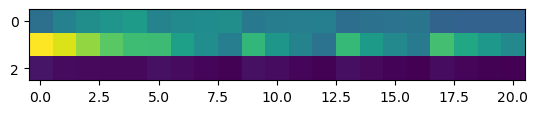

In [16]:
# sanity check: each row having roughly consistent color suggests we haven't mixed up our x, y, z dimensions 
# with all the averaging and reshaping
plt.imshow(x_mean[:, :, 0].T)

In [17]:
x_mean.shape

(21, 3, 30)

In [18]:
# build a template as average of all trials (across different conditions)
x_mean_template = x_mean.mean(axis=2)

In [19]:
x_mean_registered = np.empty_like(x_mean)
for trial_idx in range(x_mean.shape[2]):
    _x = x_mean[:, :, trial_idx]

    # adding bias col of 1s (offset)
    _x = np.hstack((np.ones((_x.shape[0], 1)), _x))

    # compute min MSE transformation back to template space
    a = np.linalg.pinv(_x[palm_idx, :]) @ x_mean_template[palm_idx, :]

    # apply and store
    x_mean_registered[:, :, trial_idx] = _x @ a

### Graph Hands

In [20]:
edge_pairs = np.array([[0, 1], [1, 2], [2, 3], [3, 4],
                       [0, 5], [5,6], [6, 7], [7, 8], 
                       [5, 9], [9, 10], [10, 11], [11, 12], 
                       [9, 13], [13, 14], [14, 15], [15, 16],
                       [13, 17], [17, 18], [18, 19], [19, 20],
                      [17, 0]])

def plot_hand(x_posisitons, y_positions, **kwargs):
    # Create a NetworkX graph
    G = nx.Graph()

    # Add nodes to the graph with (x, y) positions
    for i, (x, y) in enumerate(zip(x_posisitons, y_positions)):
        G.add_node(i, pos=(x, y))

    # Get positions of nodes
    node_positions = nx.get_node_attributes(G, 'pos')

    G.add_edges_from(edge_pairs)

    # Plot the graph
    nx.draw(G, pos=node_positions, with_labels=False, node_size=0, font_size=12, **kwargs)
    plt.plot()

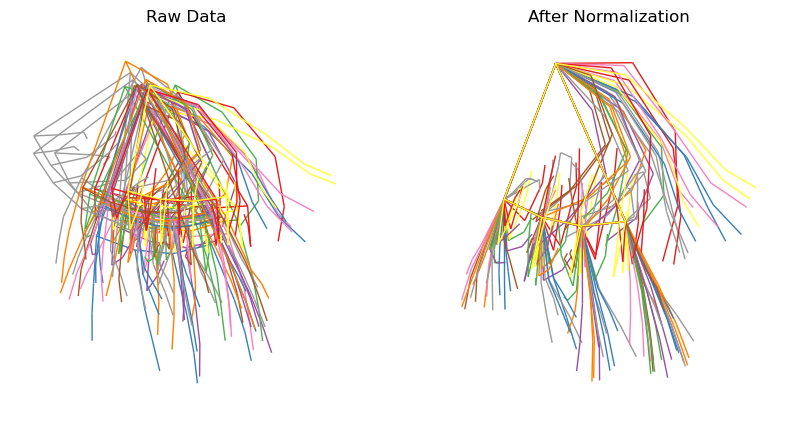

In [21]:
cmap = plt.get_cmap('Set1')

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 5)
for ax_idx, (label, x) in enumerate([('Raw Data', x_mean),
                                     ('After Normalization', x_mean_registered)]):
    plt.sca(ax[ax_idx])
    for trial_idx in range(x.shape[2]):
        _x = x[:, :, trial_idx]
        # networkx insists on a 2d array
        color = np.atleast_2d(cmap(y[trial_idx]))
        plot_hand(_x[:, 0], _x[:, 1], edge_color=color)
    ax[ax_idx].title.set_text(label)

## Classification

In [22]:
import warnings

# Suppress all future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [23]:
x_mean_registered.T.shape

(30, 3, 21)

In [24]:
z = zip(x_mean_registered.T, y)
len(list(z))

30

In [25]:
# Group by trial 
label_vals = np.unique(y)

# Initialize dictionary to store separated data
separated_data = {label: [] for label in label_vals}

# Iterate over trials and separate data based on labels
for trial, label in zip(x_mean_registered.T, y):
    separated_data[label].append(trial)

# Convert lists to arrays
for label, trials in separated_data.items():
    separated_data[label] = np.array(trials).reshape(3, 3 * 21)

In [26]:
# Set up combinations
combos = list(combinations(label_vals, NUM_POSES_WANTED))
print(len(combos))

120


In [27]:
print(len(list(combos)))

120


In [28]:
from sklearn.model_selection import cross_val_score, KFold

# initialize a knn_classifier
knn_classifier = KNeighborsClassifier(n_neighbors=3)

# construction of kfold object
kfold = KFold(n_splits= NUM_POSES_WANTED, shuffle=True)

scores = np.zeros(len(combos))

for scr_idx, comb in enumerate(combos):
    num_samples = 0
    for l in comb:
        num_samples += separated_data[l].shape[0]
                
    x_classify = np.zeros((num_samples, 21*3))
    y_subset = np.zeros(num_samples)
    sample_idx = 0 
    for l in comb:
        for t in separated_data[l]:
            x_classify[sample_idx] = t
            y_subset[sample_idx] = l
            sample_idx += 1
            
    # Perform k-fold cross-validation
    cv_scores = cross_val_score(knn_classifier, x_classify, y_subset, cv=kfold)

    # Calculate the mean and standard deviation of the cross-validation scores
    scores[scr_idx] = cv_scores.mean()

    

# Find the indices of the top n scores
# top_indices = np.argsort(scores)[::-1][:3]
# top_combos = []
# top_scores = []

# for idx in top_indices:
#     top_combos.append(combos[idx])
#     top_scores.append(scores[idx])
    
# print(top_scores)
# print(top_combos)

# Find the top score
highest_score_idx = np.argmax(scores)
highest_score = scores[highest_score_idx]
best_combo = list(combos[highest_score_idx])
print(highest_score)
print(best_combo)

1.0
[0, 3, 6]


## Ordered Hand Symbols

In [35]:
def find_best_combo(remaining_labels):
    # Set up combinations
    combos = list(combinations(remaining_labels, len(remaining_labels) - 1))
    
    # initialize a knn_classifier
    knn_classifier = KNeighborsClassifier(n_neighbors=3)

    # construction of kfold object
    kfold = KFold(n_splits= NUM_POSES_WANTED, shuffle=True)

    scores = np.zeros(len(combos))

    for scr_idx, comb in enumerate(combos):
        num_samples = 0
        for l in comb:
            num_samples += separated_data[l].shape[0]

        x_classify = np.zeros((num_samples, 21*3))
        y_subset = np.zeros(num_samples)
        sample_idx = 0 
        for l in comb:
            for t in separated_data[l]:
                x_classify[sample_idx] = t
                y_subset[sample_idx] = l
                sample_idx += 1

        # Perform k-fold cross-validation
        cv_scores = cross_val_score(knn_classifier, x_classify, y_subset, cv=kfold)

        # Calculate the mean and standard deviation of the cross-validation scores
        scores[scr_idx] = cv_scores.mean()

    # Find the top score
    highest_score_idx = np.argmax(scores)
    highest_score = scores[highest_score_idx]
    best_combo = list(combos[highest_score_idx])
    
    return best_combo

In [52]:
ordered_poses = np.empty(len(label_vals))
remaining_poses = np.copy(label_vals)

for n in range(len(label_vals) - 1, 1, -1):
    best = find_best_combo(remaining_poses)
    least_distinguished = np.setdiff1d(remaining_poses, best)[0]
    print('{}: OF: {}, BEST: {}, WORST: {}'.format(n, remaining_poses, best, least_distinguished))
    remaining_poses = np.delete(remaining_poses, np.where(remaining_poses == least_distinguished))
    ordered_poses[n] = least_distinguished
    if n == 2:
        ordered_poses[0] = best[0]
        ordered_poses[1] = best[1]

print(ordered_poses)

9: OF: [0 1 2 3 4 5 6 7 8 9], BEST: [0, 1, 2, 3, 5, 6, 7, 8, 9], WORST: 4
8: OF: [0 1 2 3 5 6 7 8 9], BEST: [0, 1, 2, 3, 5, 7, 8, 9], WORST: 6
7: OF: [0 1 2 3 5 7 8 9], BEST: [0, 1, 3, 5, 7, 8, 9], WORST: 2
6: OF: [0 1 3 5 7 8 9], BEST: [0, 1, 3, 5, 7, 9], WORST: 8
5: OF: [0 1 3 5 7 9], BEST: [0, 1, 5, 7, 9], WORST: 3
4: OF: [0 1 5 7 9], BEST: [0, 1, 5, 9], WORST: 7
3: OF: [0 1 5 9], BEST: [0, 5, 9], WORST: 1
2: OF: [0 5 9], BEST: [0, 9], WORST: 5
[0. 9. 5. 1. 7. 3. 8. 2. 6. 4.]
